<a href="https://colab.research.google.com/github/naethru/Student-managment-system/blob/main/Stock_Price_Trend_Prediction_using_Artificial_Neural_Network(ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Stock Price Prediction using Feedforward ANN

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [ ]:
#Dowloading Stock Data

df = yf.download("AAPL", start="2018-01-01", end="2024-12-31")
df.to_csv("AAPL.csv")

/tmp/ipykernel_4983/552864842.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Using only required columns
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]
#Defining Target variable
df['Target'] = df['Close'].shift(-1)
#Removing the last row
df.dropna(inplace=True)

In [ ]:
# Features and Target
X = df[['Open', 'High', 'Low', 'Volume', 'Close']]
y = df['Target']

In [ ]:
#Normalizing Data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, shuffle = False
)



In [ ]:
#Building ANN
model = Sequential()
model.add(Dense(64, activation = 'relu', input_shape = (5,)))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(1))
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9875.4502 - mae: 88.8630 - val_loss: 24169.6152 - val_mae: 154.4970
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9616.6396 - mae: 87.6061 - val_loss: 23235.1035 - val_mae: 151.4724
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8934.9199 - mae: 84.1697 - val_loss: 20925.9141 - val_mae: 143.7212
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7464.3032 - mae: 76.3279 - val_loss: 16517.5645 - val_mae: 127.6335
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5163.5059 - mae: 62.2530 - val_loss: 10556.3408 - val_mae: 101.9284
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2637.7463 - mae: 42.1437 - val_loss: 4797.4146 - val_mae: 68.5099
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 875.4767 - mae: 21.7999 - val_loss: 1449.2006 - val_mae: 37.2789
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 278.5285 - mae: 13.7900 - val_loss: 483.9609 - val_mae: 2

In [ ]:
#Prediction
predictions = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
#Evaluation
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

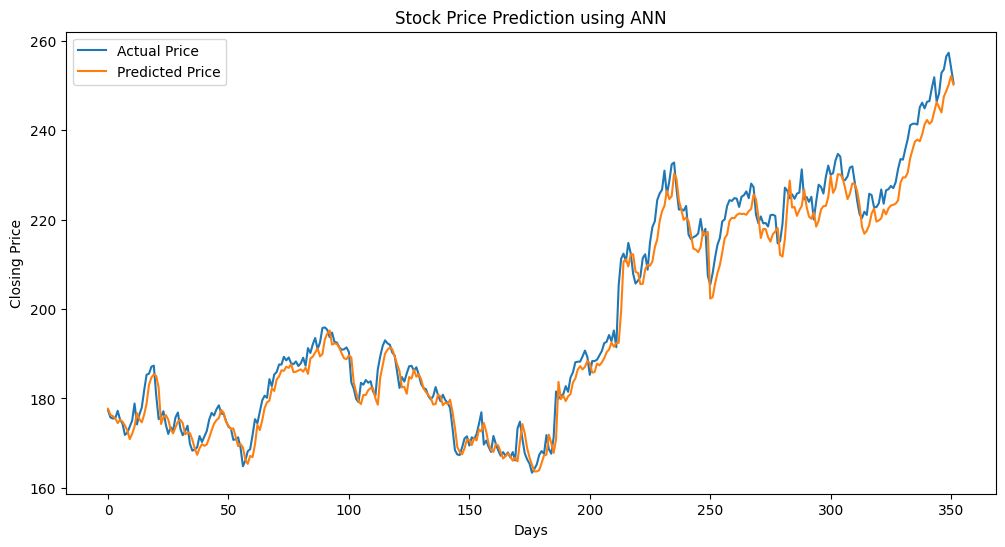

In [ ]:
#Plot
plt.figure(figsize = (12,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Stock Price Prediction using ANN")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [ ]:
#Predict Next Day
latest = scaler.transform(df[['Open', 'High', 'Low', 'Volume', 'Close']].tail(1))
next_price = model.predict(latest)
print("\nPredicted Next Closing Price:", float(next_price[0][0]))

In [ ]:
# Save Model
model.save("stock_ann_model.h5")
print("Model saved as stock_ann_model.h5")